Importing Libraries

In [367]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

Importing and plotting last 2 years stock data

C:\Users\vidiltkrelia\AppData\Local\Temp\ipykernel_2504\394720750.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download("RELIANCE.NS",start="2023-12-01",end="2025-12-01")
[*********************100%***********************]  1 of 1 completed


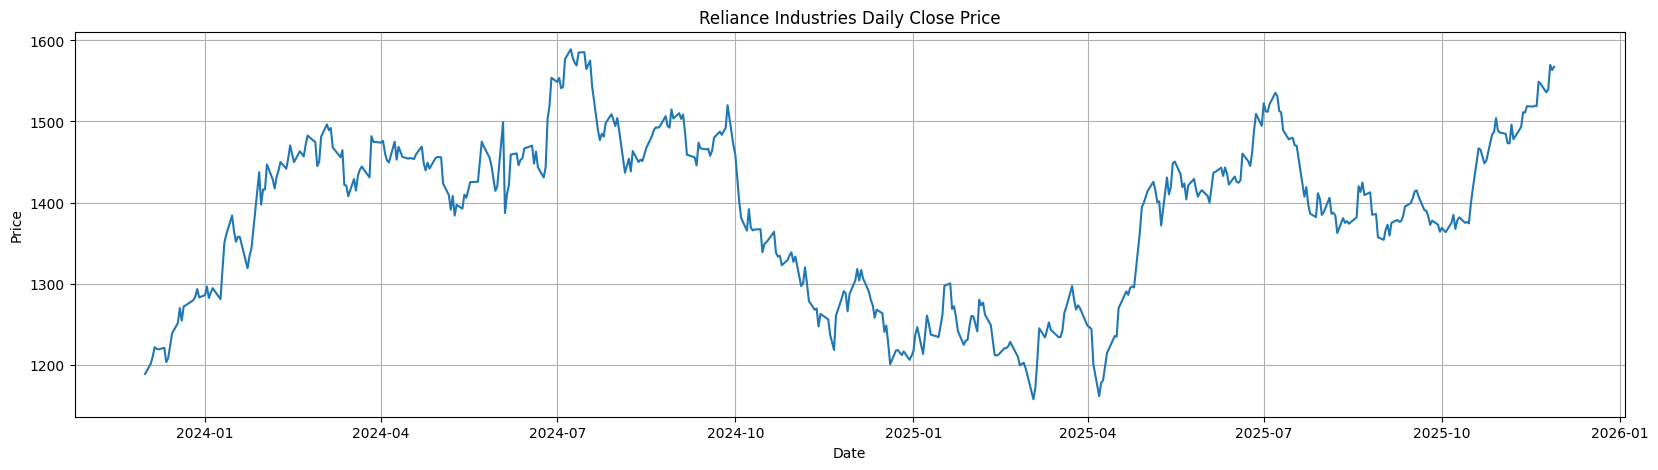

Price             Close         High          Low         Open    Volume
Date                                                                    
2023-12-01  1188.354492  1189.396705  1180.065864  1180.264346  14342842
2023-12-04  1201.209229  1215.999781  1190.488650  1215.999781  15590990
2023-12-05  1209.919800  1211.458460  1201.928896  1210.540208  12693624
2023-12-06  1221.509155  1227.390551  1208.554986  1214.560585  16422442
2023-12-07  1219.499023  1221.434648  1212.029286  1220.963162   8142096
...                 ...          ...          ...          ...       ...
2025-11-24  1535.900024  1550.000000  1531.800049  1550.000000  18433951
2025-11-25  1539.699951  1559.599976  1525.099976  1535.900024  15033482
2025-11-26  1569.900024  1571.599976  1540.500000  1542.300049  14054299
2025-11-27  1563.400024  1575.500000  1556.000000  1575.000000   9794643
2025-11-28  1567.500000  1581.300049  1563.000000  1568.000000   8959508

[494 rows x 5 columns]


In [368]:
df=yf.download("RELIANCE.NS",start="2023-12-01",end="2025-12-01")
df.columns = df.columns.droplevel(1)
plt.figure(figsize=(20, 5))
plt.plot(df["Close"])
plt.title("Reliance Industries Daily Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()
print(df)

SMA Function

In [369]:
def SMA(df, n):
    df[f"SMA_{n}"] = np.nan

    for i in range(n-1, len(df)):
        Sum = 0
        for j in range(i-n+1, i+1):
            Sum += df.iloc[j]["Close"]

        df.loc[df.index[i], f"SMA_{n}"] = Sum / n
        



EMA Function

In [370]:
def EMA(df,n):
    df[f"EMA_{n}"] = np.nan
    sum=0

    for i in range(n):
       sum+=df.iloc[i]["Close"]
    df.loc[df.index[n-1], f"EMA_{n}"]=sum/n 

    for i in range(n,len(df)):
        df.loc[df.index[i], f"EMA_{n}"]=((df.iloc[i]["Close"]-df.loc[df.index[i-1], f"EMA_{n}"])*(2/(n+1)))+df.loc[df.index[i-1], f"EMA_{n}"]

Calculating EMA 50 and EMA 200 for finding golden crossovers

In [371]:
SMA(df,5)
EMA(df,50)
EMA(df,200)
SMA(df,14)
EMA(df,14)
print(df)

Price             Close         High          Low         Open    Volume  \
Date                                                                       
2023-12-01  1188.354492  1189.396705  1180.065864  1180.264346  14342842   
2023-12-04  1201.209229  1215.999781  1190.488650  1215.999781  15590990   
2023-12-05  1209.919800  1211.458460  1201.928896  1210.540208  12693624   
2023-12-06  1221.509155  1227.390551  1208.554986  1214.560585  16422442   
2023-12-07  1219.499023  1221.434648  1212.029286  1220.963162   8142096   
...                 ...          ...          ...          ...       ...   
2025-11-24  1535.900024  1550.000000  1531.800049  1550.000000  18433951   
2025-11-25  1539.699951  1559.599976  1525.099976  1535.900024  15033482   
2025-11-26  1569.900024  1571.599976  1540.500000  1542.300049  14054299   
2025-11-27  1563.400024  1575.500000  1556.000000  1575.000000   9794643   
2025-11-28  1567.500000  1581.300049  1563.000000  1568.000000   8959508   

Price      

In [372]:
# n=5
# plt.figure(figsize=(20, 6))
# plt.plot(df[f"EMA_50"],color="orange",label="EMA 50")
# plt.plot(df[f"EMA_200"],color="red",label="EMA 200")
# plt.plot(df["Close"],color="blue",label="Closing Prices")
# plt.title("Reliance Industries Daily Close Price")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.grid(True)
# plt.legend()
# plt.show()

MACD using EMA function(Also plotting the MACD Lines against the stock prices for seeing the patterns) (Father suggested to do this)

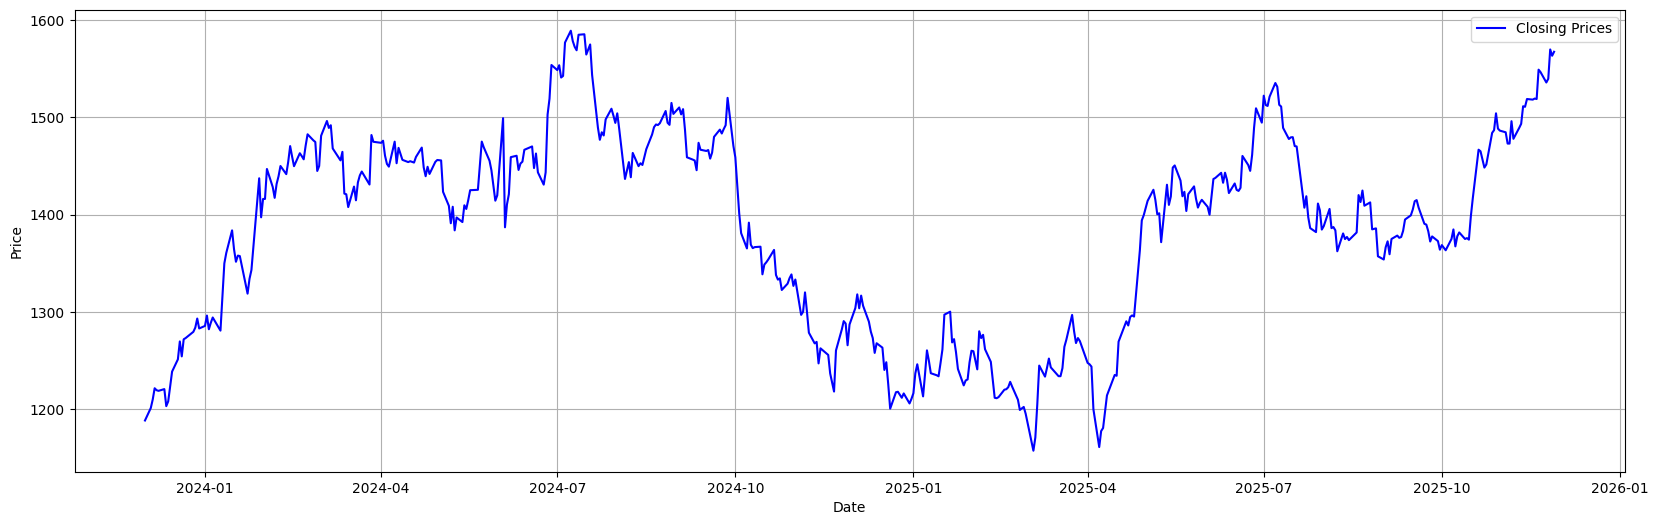

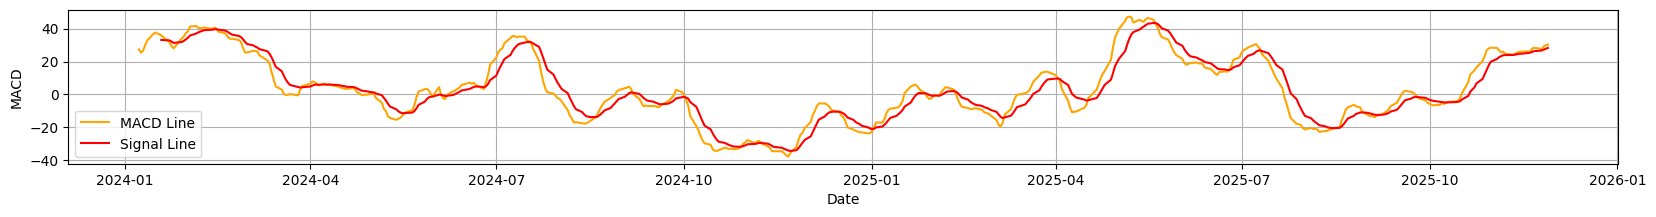

In [373]:
EMA(df,12)
EMA(df,26)

def MACD(df):
    df["MACD_Line"]=df["EMA_12"]-df["EMA_26"]
    df["Signal_Line"] = np.nan
    sum=0

    for i in range(26,35):
       sum+=df.iloc[i]["MACD_Line"]
    df.loc[df.index[34], "Signal_Line"]=sum/9

    for i in range(35,len(df)):
        df.loc[df.index[i], "Signal_Line"]=((df.iloc[i]["MACD_Line"]-df.loc[df.index[i-1], "Signal_Line"])*(2/(9+1)))+df.loc[df.index[i-1], "Signal_Line"]
MACD(df)

# print(df)

plt.figure(figsize=(20, 6))
plt.plot(df["Close"], color="blue", label="Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(20, 2))
plt.plot(df["MACD_Line"], color="orange", label="MACD Line")
plt.plot(df["Signal_Line"], color="red", label="Signal Line")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.grid(True)
plt.show()



RSI

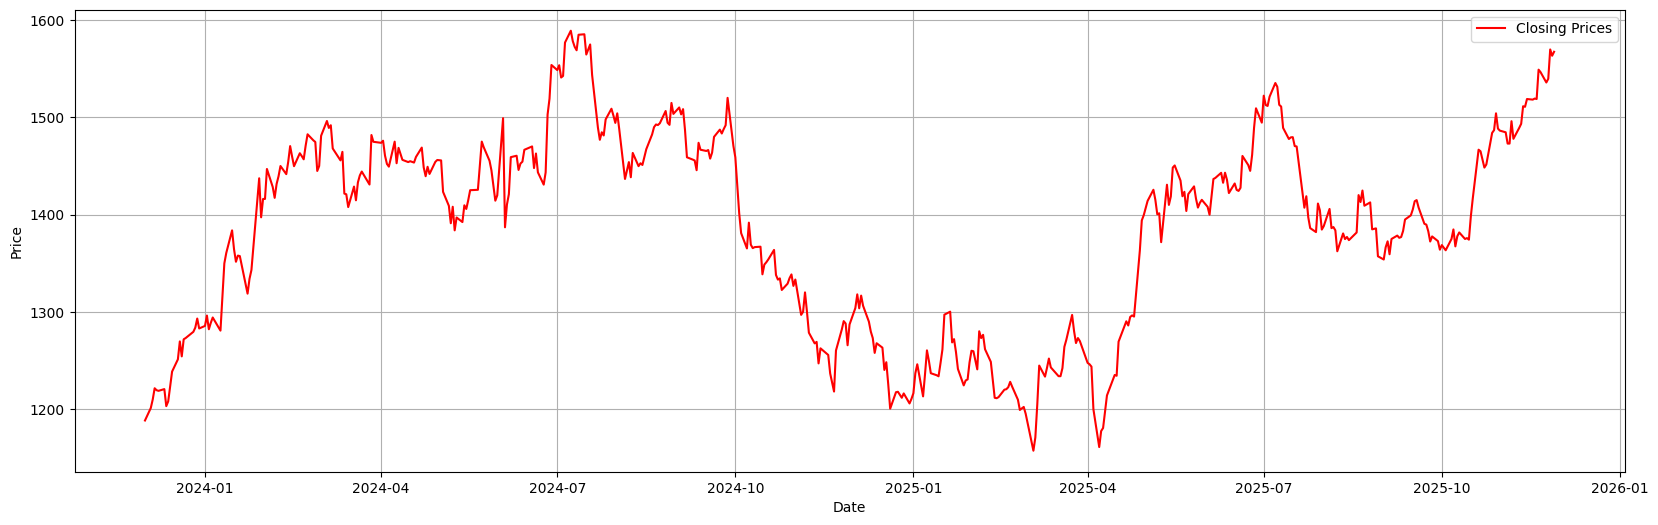

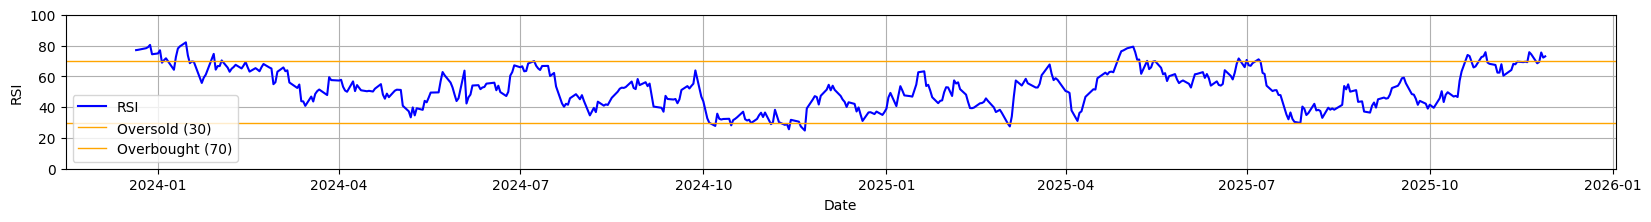

In [374]:
n=14
gain=0
loss=0

df["RSI"]=np.nan

for i in range(1,n+1):
    difference=df.loc[df.index[i],"Close"]-df.loc[df.index[i-1],"Close"]
    if difference>0:
        gain+=difference
    elif difference<0:
        loss+=(-difference)

avg_gain=gain/14
avg_loss=loss/14
df.loc[df.index[n],"RSI"]=100-(100/(1+(avg_gain/avg_loss)))

for i in range(n+1,len(df)):
    change=df.loc[df.index[i],"Close"]-df.loc[df.index[i-1],"Close"]
    if change > 0:
        gain = change
        loss = 0
    else:
        gain = 0
        loss = -change
    
    avg_gain = (avg_gain*(n-1) + gain) / n
    avg_loss = (avg_loss*(n-1) + loss) / n
    df.loc[df.index[i],"RSI"]=100-(100/(1+(avg_gain/avg_loss)))


plt.figure(figsize=(20, 6))
plt.plot(df["Close"], color="red", label="Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(20, 2))
plt.plot(df["RSI"], color="blue", label="RSI")
plt.axhline(30,color="orange",linewidth=1,label="Oversold (30)")
plt.axhline(70,color="orange",linewidth=1,label="Overbought (70)")
plt.ylim(0, 100)
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.grid(True)
plt.show()






Stochastic Oscillator(Plot included)

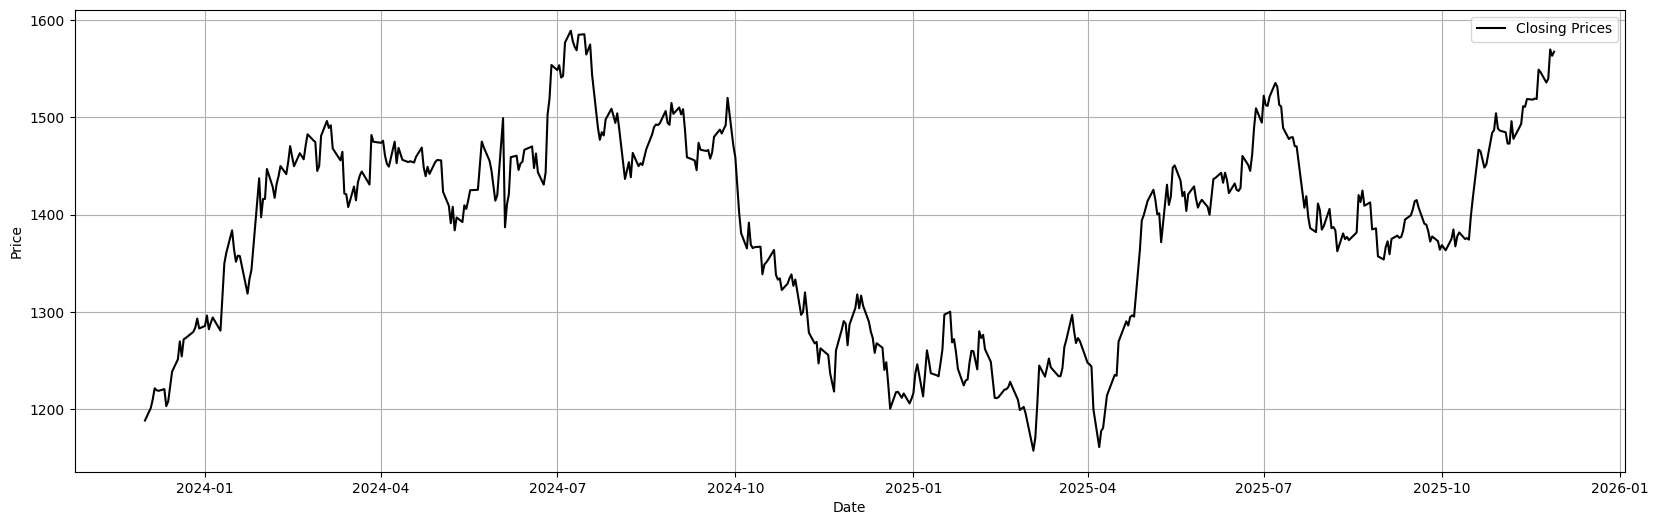

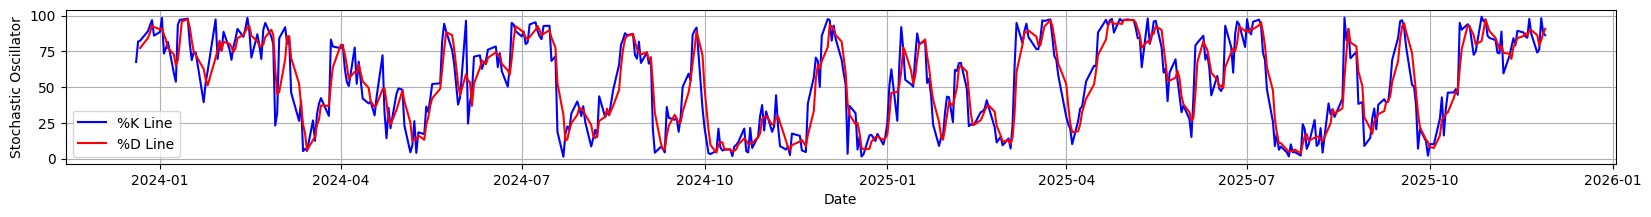

In [375]:
n=14
df["%K"]=np.nan
for i in range(n-1,len(df)):
    max=df.loc[df.index[i],"High"]
    min=df.loc[df.index[i],"Low"]
    for j in range(i-n+1,i+1):
        if df.loc[df.index[j],"High"]>max:
            max=df.loc[df.index[j],"High"]
        elif df.loc[df.index[j],"Low"]<min:
            min=df.loc[df.index[j],"Low"]
    df.loc[df.index[i],"%K"]=100*((df.loc[df.index[i],"Close"])-min)/(max-min)

df["%D"]=np.nan

n=3
for i in range(n-1, len(df)):
    Sum = 0
    for j in range(i-n+1, i+1):
        Sum += df.iloc[j]["%K"]
    df.loc[df.index[i], "%D"] = Sum / n

plt.figure(figsize=(20, 6))
plt.plot(df["Close"], color="black", label="Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(20, 2))
plt.plot(df["%K"], color="blue", label="%K Line")
plt.plot(df["%D"], color="red", label="%D Line")
plt.xlabel("Date")
plt.ylabel("Stochastic Oscillator")
plt.legend()
plt.grid(True)
plt.show()




In [376]:
print(df)

Price             Close         High          Low         Open    Volume  \
Date                                                                       
2023-12-01  1188.354492  1189.396705  1180.065864  1180.264346  14342842   
2023-12-04  1201.209229  1215.999781  1190.488650  1215.999781  15590990   
2023-12-05  1209.919800  1211.458460  1201.928896  1210.540208  12693624   
2023-12-06  1221.509155  1227.390551  1208.554986  1214.560585  16422442   
2023-12-07  1219.499023  1221.434648  1212.029286  1220.963162   8142096   
...                 ...          ...          ...          ...       ...   
2025-11-24  1535.900024  1550.000000  1531.800049  1550.000000  18433951   
2025-11-25  1539.699951  1559.599976  1525.099976  1535.900024  15033482   
2025-11-26  1569.900024  1571.599976  1540.500000  1542.300049  14054299   
2025-11-27  1563.400024  1575.500000  1556.000000  1575.000000   9794643   
2025-11-28  1567.500000  1581.300049  1563.000000  1568.000000   8959508   

Price      

Bollinger Bands

In [377]:
n = 20
df["Middle_Band"]=np.nan
df["Upper_Band"]=np.nan
df["Lower_Band"]=np.nan

df["Middle_Band"] = df["Close"].rolling(n).mean()
df["Upper_Band"] = df["Middle_Band"] + 2 * df["Close"].rolling(n).std()
df["Lower_Band"] = df["Middle_Band"] - 2 * df["Close"].rolling(n).std()

Finding the indicators on 29th April 2025

In [378]:
print(df.loc["2025-04-29","SMA_14"])
print(df.loc["2025-04-29","EMA_14"])
print(df.loc["2025-04-29","MACD_Line"])
print(df.loc["2025-04-29","Signal_Line"])
print(df.loc["2025-04-29","RSI"])
print(df.loc["2025-04-29","%K"])
print(df.loc["2025-04-29","%D"])
print(df.loc["2025-04-29","Middle_Band"])
print(df.loc["2025-04-29","Upper_Band"])
print(df.loc["2025-04-29","Lower_Band"])



1263.7598179408483
1291.4502008635197
28.61801347441292
12.875780164461057
76.28992081846087
96.21683192613798
94.06470251198164
1258.6605285644532
1375.527264586702
1141.7937925422045


Indicators from AngelOne

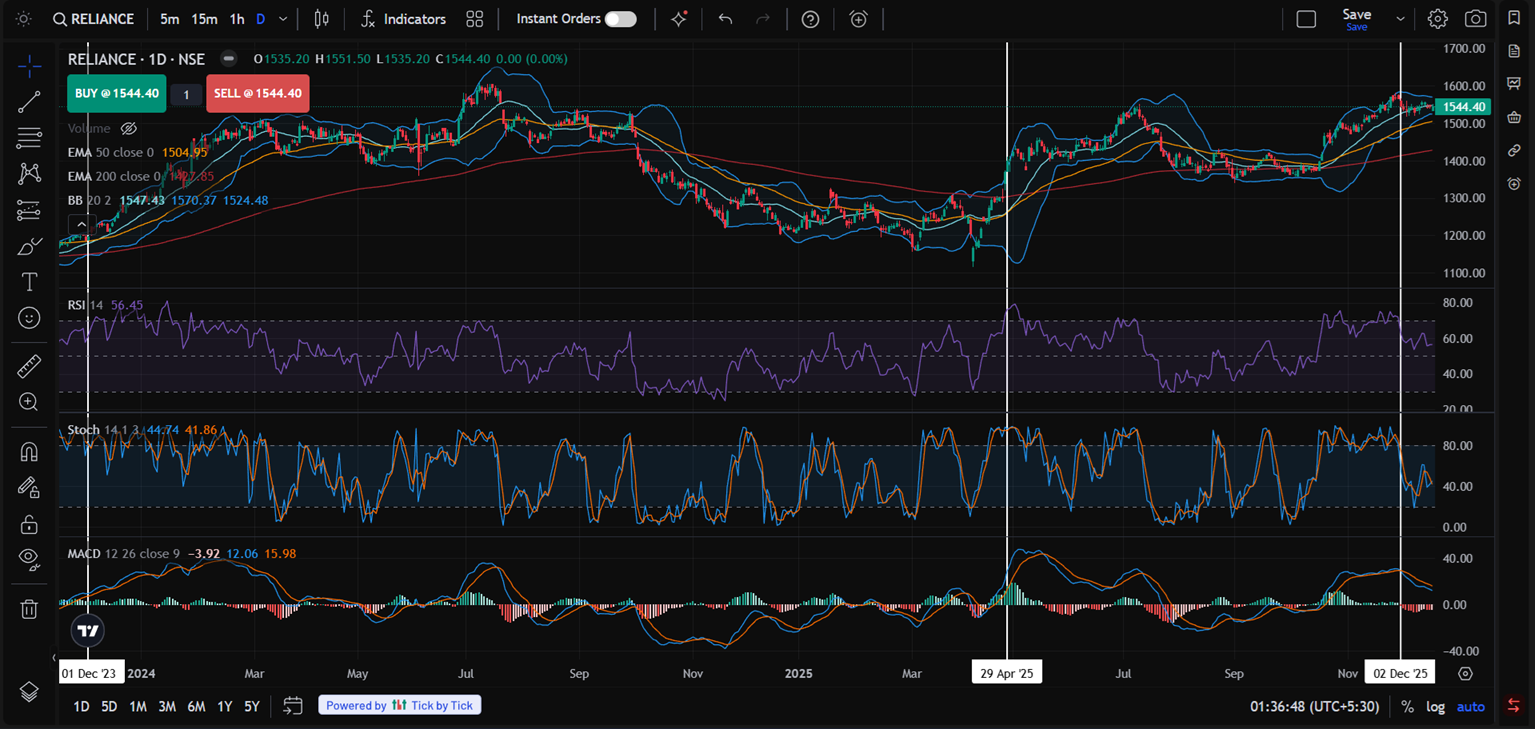